# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Pasion, Kyla Zarina R.
- _Student No._: 2024-09224
- _Section_: THR-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

### Problem 1: Root Finding
![Plot of the given function](./Figures/e7_figure1.png)

Figure 1. Graph of the given function f(x)

![Plots of the convergence of the values of the root 1](./Figures/e7_figure2.png)

Figure 2. Convergence of numerical methods for root 1

![Plots of the convergence of the values of the root 1](./Figures/e7_figure3.png)

Figure 3. Convergence of numerical methods for root 2

![Plots of the convergence of the values of the root 1](./Figures/e7_figure4.png)

Figure 4. Convergence of numerical methods for root 3

### Report discussion

The convergence plots show how the estimated roots change with each iteration. Newton-Raphson generally converges rapidly for Roots 1 and 3, while Fixed-Point and Bisection may require more iterations. For Root 2, Bisection does not converge because the function touches the x-axis without changing sign, so the interval does not satisfy the method's sign-change requirement. The Secant method also exhibits initial oscillations for some starting guesses before approaching the root.

The results highlight the advantages and limitations of each method. Newton-Raphson can converge quickly but requires the derivative and may struggle when the slope is near zero. The Secant method avoids calculating the derivative but depends on appropriate initial guesses. Fixed-Point iteration is straightforward to implement, although its success depends on the chosen transformation and relaxation parameter. Bisection is reliable when the interval contains a sign-changing root, but it converges more slowly and cannot directly locate roots where the function does not change sign. Therefore, selecting a suitable method depends on the function's behavior and the available information.


### Other comments
- None :)


---
## Section 2: Code

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

In [11]:
# Function
def f(x):
    return (-(x)**5 + 4*(x)**4 - 4*(x)**3
            + (x**2)*np.exp(x) - 2*(x)**2
            - 4*x*np.exp(x) + 8*x + 4*np.exp(x) - 8)


# Analytical derivative
def df(x):
    return (-5*x**4 + 16*x**3 - 12*x**2
            - 4*x + 8
            + (x**2 - 2*x)*np.exp(x))

In [12]:
# Fixed-point method (relaxation)
def fixedpoint(f,xold,kmax=200,tol=1.e-8):
    x_values = [xold]
    for k in range(1,kmax):
        xnew = f(xold)
        xdiff = xnew - xold
        x_values.append(xnew)
        if abs(xdiff/xnew) < tol:
            break
        xold = xnew
    else:
        xnew = None
    return xnew, x_values

In [13]:
# Bisection method
def bisection(f, x0, x1, kmax=200, tol=1e-8):
    f0, f1 = f(x0), f(x1)
    if f0*f1 > 0:            
        return None, []
    history = []
    for k in range(1, kmax):
        x2 = (x0 + x1)/2
        f2 = f(x2)
        if f2 == 0:          
            history.append(x2)
            return x2, history
        if f0*f2 < 0:
            x1, f1 = x2, f2
        else:
            x0, f0 = x2, f2
        x2new = (x0 + x1)/2
        history.append(x2new)
        if abs(x2new - x2)/abs(x2new) < tol:
            break
    else:
        x2new = None
    return x2new, history

In [14]:
# Newton's method
def newton(f, df, x0, kmax=200, tol=1.e-8):
    xold = x0
    history = [xold]
    for k in range(1, kmax):
        fx = f(xold)
        if abs(fx) < tol:         
            return xold, history
        dfx = df(xold)
        if abs(dfx) < 1e-14:  
            return None, history
        xnew = xold - fx / dfx  
        history.append(xnew)  
        xold = xnew
    return None, history

In [15]:
# Secant method
def secant(f,x0,x1,kmax=200,tol=1.e-8):
    f0 = f(x0)
    history = [x0, x1]
    for k in range(1,kmax):
        f1 = f(x1)
        if abs(f1 - f0) < 1e-14: 
            break
        ratio = (x1 - x0)/(f1 - f0)
        x2 = x1 - f1*ratio
        xdiff = abs(x2-x1)
        x0, x1 = x1, x2
        f0 = f1

        history.append(x2)
        if abs(xdiff/x2) < tol:
            break
    else:
        x2 = None

    return x2, history

Root 1:
Fixed-Point: -1.1926857629960477
Bisection: -1.1926857605576515
Secant: -1.1926857650225988
Newton: -1.1926857650226048

Root 2:
Fixed-Point: 1.9999999476177657
Bisection: None
Secant: 2.0000000393171709
Newton: 1.9999685443558120

Root 3:
Fixed-Point: 4.5958635547546649
Bisection: 4.5958635509014130
Secant: 4.5958635649223725
Newton: 4.5958635649237367



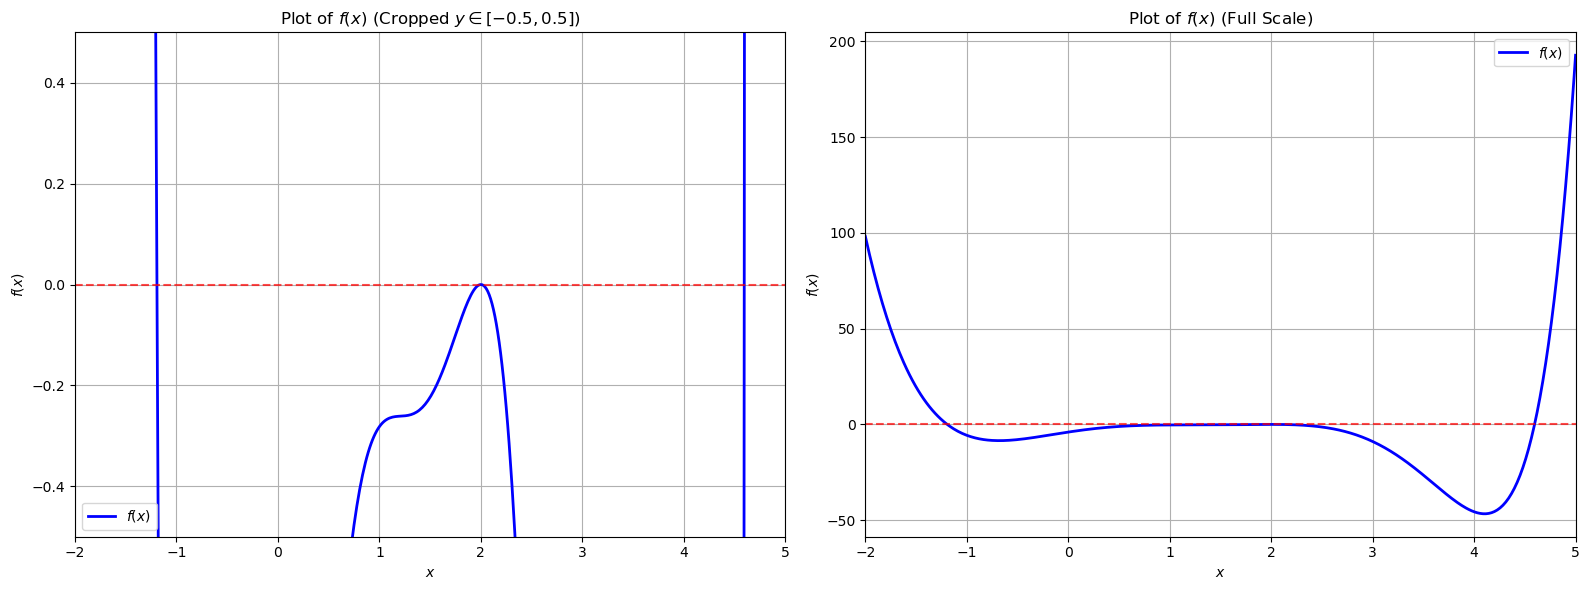

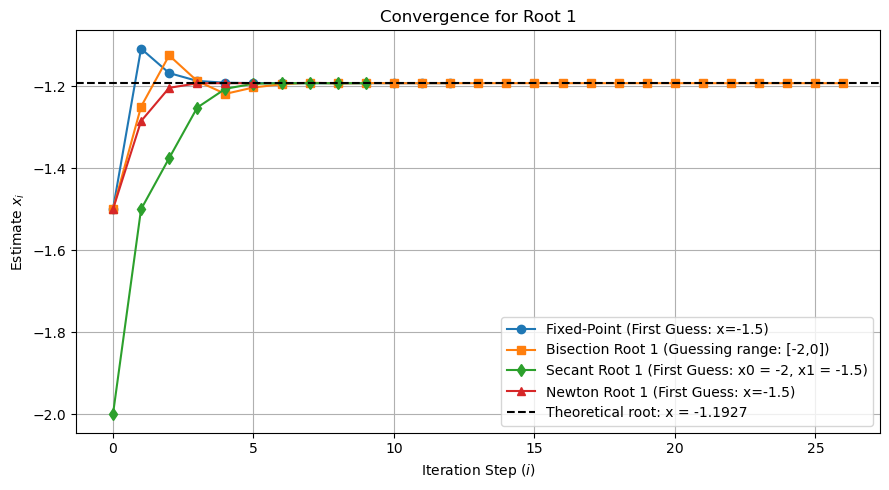

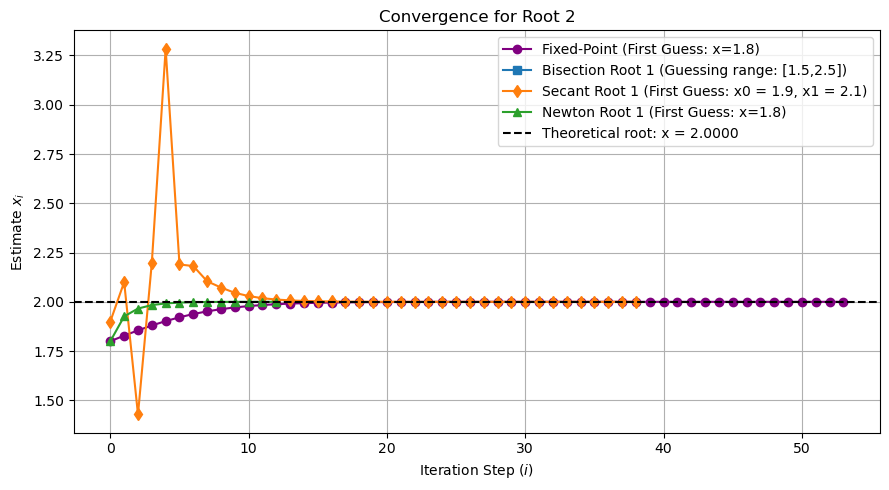

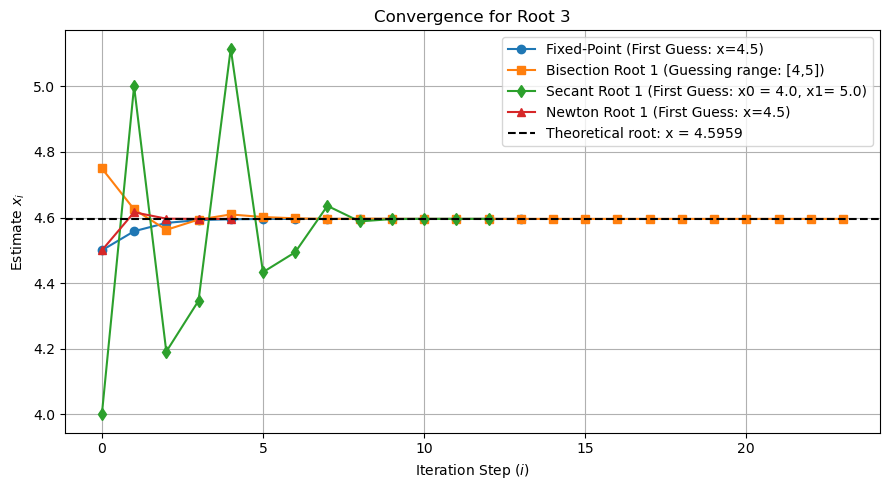

In [16]:
x_values = np.linspace(-2, 5, 500)
y_values = f(x_values)

g1 = lambda x: x + 0.02 * f(x)
g2 = lambda x: x + 0.05 * df(x)
g3 = lambda x: x - 0.003 * f(x)

# Root 1
root1_fp, hist1_fp = fixedpoint(g1, xold=-1.5)
root1_bi, hist1_bi = bisection(f, x0=-2.0, x1=0.0)
root1_sc, hist1_sc = secant(f, x0=-2.0, x1=-1.5)
root1_nt, hist1_nt = newton(f, df, x0=-1.5)

print("Root 1:")
print(f"Fixed-Point: {root1_fp:.16f}")
print(f"Bisection: {root1_bi:.16f}")
print(f"Secant: {root1_sc:.16f}")
print(f"Newton: {root1_nt:.16f}\n")

# Root 2
root2_fp, hist2_fp = fixedpoint(g2, xold=1.8)
root2_bi, hist2_bi = bisection(f, x0=1.5, x1=2.5) # f'(x) changes sign at double root
root2_sc, hist2_sc = secant(f, x0=1.9, x1=2.1)
root2_nt, hist2_nt = newton(f, df, x0=1.8)

print("Root 2:")
print(f"Fixed-Point: {root2_fp:.16f}")
print(f"Bisection: {root2_bi}")
print(f"Secant: {root2_sc:.16f}")
print(f"Newton: {root2_nt:.16f}\n")


# Root 3
root3_fp, hist3_fp = fixedpoint(g3, xold=4.5)
root3_bi, hist3_bi = bisection(f, x0=4.0, x1=5.0)
root3_sc, hist3_sc = secant(f, x0=4.0, x1=5.0)
root3_nt, hist3_nt = newton(f, df, x0=4.5)

print("Root 3:")
print(f"Fixed-Point: {root3_fp:.16f}")
print(f"Bisection: {root3_bi:.16f}")
print(f"Secant: {root3_sc:.16f}")
print(f"Newton: {root3_nt:.16f}\n")

# Exact analytical baseline roots for error reference
root1 = -1.1926857650
root2 = 2.0
root3 = 4.5958635649

# First plot: Cropped
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(x_values, y_values, color='blue', linewidth=2, label=r'$f(x)$')
ax1.axhline(0, color='red', linestyle='--', alpha=0.7)
ax1.set_ylim(-0.5, 0.5)
ax1.set_xlim(-2, 5)
ax1.set_xlabel('$x$')
ax1.set_ylabel('$f (x)$')
ax1.set_title('Plot of $f(x)$ (Cropped $y \in [-0.5, 0.5]$)')
ax1.grid(True)
ax1.legend()

# Second plot: Full scale
ax2.plot(x_values, y_values, color='blue', linewidth=2, label=r'$f(x)$')
ax2.axhline(0, color='red', linestyle='--', alpha=0.7)
ax2.set_xlim(-2, 5)
ax2.set_xlabel('$x$')
ax2.set_ylabel('$f (x)$')
ax2.set_title('Plot of $f(x)$ (Full Scale)')
ax2.grid(True)
ax2.legend()
plt.tight_layout()
plt.show()

# Plot for Root 1
plt.figure(figsize=(9, 5))
plt.plot(hist1_fp, marker='o', label="Fixed-Point (First Guess: x=-1.5)") 
plt.plot(hist1_bi, marker='s', label="Bisection Root 1 (Guessing range: [-2,0])")
plt.plot(hist1_sc, marker='d', label="Secant Root 1 (First Guess: x0 = -2, x1 = -1.5)")
plt.plot(hist1_nt, marker='^', label="Newton Root 1 (First Guess: x=-1.5)")
plt.axhline(root1, color='black', linestyle='--', linewidth=1.5, label=f"Theoretical root: x = {root1:.4f}")
plt.xlabel('Iteration Step ($i$)')
plt.ylabel('Estimate $x_i$')
plt.title('Convergence for Root 1')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot for Root 2
plt.figure(figsize=(9, 5))
plt.plot(hist2_fp, marker='o', color='purple', label="Fixed-Point (First Guess: x=1.8)") 
plt.plot(hist2_bi, marker='s', label="Bisection Root 1 (Guessing range: [1.5,2.5])")
plt.plot(hist2_sc, marker='d', label="Secant Root 1 (First Guess: x0 = 1.9, x1 = 2.1)")
plt.plot(hist2_nt, marker='^', label="Newton Root 1 (First Guess: x=1.8)")
plt.axhline(root2, color='black', linestyle='--', linewidth=1.5, label=f"Theoretical root: x = {root2:.4f}")
plt.xlabel('Iteration Step ($i$)')
plt.ylabel('Estimate $x_i$')
plt.title('Convergence for Root 2')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot for Root 3
plt.figure(figsize=(9, 5))
plt.plot(hist3_fp, marker='o', label="Fixed-Point (First Guess: x=4.5)")
plt.plot(hist3_bi, marker='s', label="Bisection Root 1 (Guessing range: [4,5])")
plt.plot(hist3_sc, marker='d', label="Secant Root 1 (First Guess: x0 = 4.0, x1= 5.0)")
plt.plot(hist3_nt, marker='^', label="Newton Root 1 (First Guess: x=4.5)")
plt.axhline(root3, color='black', linestyle='--', linewidth=1.5, label=f"Theoretical root: x = {root3:.4f}")
plt.xlabel('Iteration Step ($i$)')
plt.ylabel('Estimate $x_i$')
plt.title('Convergence for Root 3')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Problem 1 code summary

This code implements four numerical methods: fixed-point iteration, bisection, secant, and Newton-Raphson to approximate the roots of the given function. Each method uses different initial values and convergence criteria to find the roots, while the iteration histories are stored to compare their convergence behavior. The function and convergence plots help visualize the roots and evaluate how effectively each method approaches the expected solutions.

---